SWC Lab meeting plots:
- diff in prediction accuracy bars, sessions and mouse averages [done]
- diff in prediction accuracy first and second half [done]
- diff in prediction accuracy first and second half but for the first session [done]

Supplementary:
- pred.acc. diff over time [done]
- pred acc. diff top to bottom of arena [done]
- compare to homings
- is the pa of postflip increasing or preflip decreasing?

In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

barrier_sesh_by_mouse = {'JAL003': ['2023_08_22','2023_08_25','2023_08_29','2023_09_01','2023_09_04','2023_09_07'],
                         'JAL004': ['2023_08_21','2023_08_24','2023_08_28','2023_09_03','2023_09_11','2023_09_19'],
                         'JAL005': ['2023_09_05','2023_09_08','2023_09_14','2023_09_21','2023_09_26','2023_09_28'],
                         'JAL006': ['2024_03_11','2024_03_14','2024_03_18','2024_03_21','2024_03_25','2024_03_28','2024_04_01','2024_04_05'],
                         'JAL007': ['2024_03_12','2024_03_15','2024_03_19','2024_03_22','2024_03_26','2024_04_04','2024_04_09','2024_04_16','2024_04_23'],
                         'JAL008': ['2024_04_25','2024_04_29','2024_05_7','2024_05_10','2024_05_14']}

In [6]:
%load_ext autoreload
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import extract_pa_across_sesh

import numpy as np
import matplotlib.pyplot as plt
import os
import dill as pickle
from JR_test_scripts.trial_heading_angle import initial_heading_angle
from behave_analysis.process.process import Process
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
%autoreload
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
# save_path = r"Z:\Jasmine_Laurence\SWClabmeeting\running_only"
save_path = r"Z:\Jasmine_Laurence\Cosyne"
conditions = ['barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']
settings = 'all_angles_fr'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm', 'all_angles_fr_excl_stationary'

In [50]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

Preflip vs Postflip

In [51]:
"""Mouse averages"""
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_pa = {}
for key in pa.keys():
    if key not in m_pa:
        m_pa[key] = np.zeros((len(unique_mouse),len(conditions)))
for idx, a in enumerate(all_angles):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_pa[a][m_idx,:] = np.mean(pa[a][this_mouse,:], axis=0)

In 22 of 25 sessions open side is better decoded than closed side in pre flip condition
In 15 of 25 sessions open side is better decoded than closed side in post flip condition


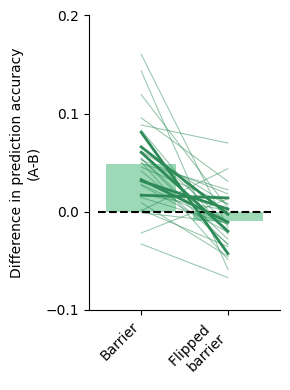

In [52]:
''' Plot the difference in pa for two goals'''
c = ['h_preflipbar_a','h_postflipbar_a']
cond = ['Barrier','Flipped \nbarrier']

fig, axs = plt.subplots(1,1,figsize = (3,4))

diff = pa[c[0]] - pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .5)
for p in diff:
    axs.plot(conditions,p,color = 'seagreen',alpha = .5, linewidth = .75)
axs.plot([-.5,len(conditions)-.5],[0,0],'--k')
diff = m_pa[c[0]] - m_pa[c[1]]
for m, p in enumerate(diff):
    axs.plot(conditions, p, linewidth = 2, label = unique_mouse[m], color = 'seagreen')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('Cosyne_pa_diff_allsesh_'+settings+'.png'), dpi = 300)

diff = pa[c[0]] - pa[c[1]]
print('In ' + str(np.sum(diff[:,0] > 0)) + ' of ' + str(len(diff[:,0])) + ' sessions open side is better decoded than closed side in pre flip condition')
print('In ' + str(np.sum(diff[:,1] < 0)) + ' of ' + str(len(diff[:,1])) + ' sessions open side is better decoded than closed side in post flip condition')

First half vs second half

In [55]:
time_cond = ["first_half", "second_half"]
sessy, all_names, avg_pa, pa = extract_pa_across_sesh(
    all_angles, experiments_objects, conditions, all_features, settings, bar_angles=False, time_cond=time_cond
)

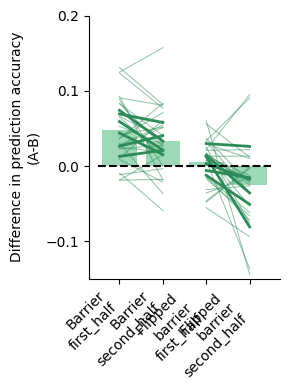

In [49]:
'''Plot diff in prediction accuracy in first vs second half averaged by mouse'''
fig, axs = plt.subplots(1,1, figsize = (3,4))
angle = ['h_preflipbar_a','h_postflipbar_a']
aligned = []
name = []
for c_idx, c in enumerate(conditions):
    for t_idx, t in enumerate(time_cond):
        if len(aligned) == 0:
            aligned = pa[angle[0]][:,c_idx,t_idx] - pa[angle[1]][:,c_idx,t_idx]
        else:
            aligned = np.vstack((aligned, pa[angle[0]][:,c_idx,t_idx] - pa[angle[1]][:,c_idx,t_idx]))
        name.append(str(cond[c_idx] + '\n' + t))

not_all_names = all_names

mouse_ID = [x[:6] for x in not_all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_aligned = np.zeros((len(unique_mouse),np.shape(aligned)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_aligned[m_idx,:] = np.mean(aligned[:,this_mouse], axis=1)

for i in [0,2]:
    axs.bar(name[i:i+2],np.nanmean(aligned[i:i+2,:],axis=1),color = 'mediumseagreen',alpha = .5)
    axs.plot(name[i:i+2],aligned[i:i+2,:],color = 'seagreen',alpha = .5, linewidth = .75)
    axs.plot(name[i:i+2],mean_aligned[:,i:i+2].T, linewidth = 2, color = 'seagreen')
axs.plot([-.5,np.shape(aligned)[0]-.5],[0,0],'--k')
axs.set_xticks(np.arange(np.shape(aligned)[0]))
axs.set_xticklabels(name,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.15,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(save_path+'/'+str('Cosyne_' + settings + 'diff_pa_first_second_half_all_avg.png'), dpi = 300)

In [24]:
"""Stats on the difference between first vs second half per condition
permutation"""
for i in [0,1,2]:
    d1 = aligned[i,:]
    d2 = aligned[i+1,:]
    real_stat = np.abs(np.mean(d1)-np.mean(d2))
    print('real stat: ' + str(real_stat))
    d = np.hstack((d1,d2))
    shuffled = np.zeros(1000)
    for j in np.arange(1000):
        idx = np.random.uniform(low = 0,high = 1, size =len(d))
        d_sort = d[np.argsort(idx)]
        shuffled[j] = np.abs(np.mean(d_sort[:len(d1)]) - np.mean(d_sort[len(d1):]))
    print(np.sum(shuffled > real_stat)/1000)

real stat: 0.015700969317716765
0.219
real stat: 0.02694213560375952
0.016
real stat: 0.03133470009977266
0.02


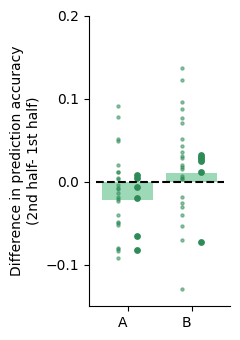

In [60]:
"""Is preflip prediction accuracy increasing? Is postflip decreasing?"""
angle = ['h_preflipbar_a','h_postflipbar_a']
pre_aligned = []
post_aligned = []
name = []
for c_idx, c in enumerate(conditions):
    if len(pre_aligned) == 0:
        pre_aligned = pa[angle[0]][:,c_idx,1] - pa[angle[0]][:,c_idx,0]
        post_aligned = pa[angle[1]][:,c_idx,1] - pa[angle[1]][:,c_idx,0]
    else:
        pre_aligned = np.vstack((pre_aligned, pa[angle[0]][:,c_idx,1] - pa[angle[0]][:,c_idx,0]))
        post_aligned = np.vstack((post_aligned,pa[angle[1]][:,c_idx,1] - pa[angle[1]][:,c_idx,0]))
    name.append(str(cond[c_idx]))

if np.shape(pre_aligned)[1] == 26:
    pre_aligned = np.delete(pre_aligned,15,1)
    post_aligned = np.delete(post_aligned,15,1)
    not_all_names = all_names[:15] + all_names[16:]
else:
    not_all_names = all_names

mouse_ID = [x[:6] for x in not_all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_pre_aligned = np.zeros((len(unique_mouse),np.shape(pre_aligned)[0]))
mean_post_aligned = np.zeros((len(unique_mouse),np.shape(post_aligned)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_pre_aligned[m_idx,:] = np.mean(pre_aligned[:,this_mouse], axis=1)
    mean_post_aligned[m_idx,:] = np.mean(post_aligned[:,this_mouse], axis=1)


"""Flipped barrier: Is preflip prediction accuracy decreasing? Is postflip increasing?"""
fig, axs = plt.subplots(1,1, figsize = (2.5,3.5))

# plot the pred acc preflip
axs.bar(0,np.nanmean(pre_aligned[1,:]),color = 'mediumseagreen',alpha = .5)
axs.scatter((np.ones(len(pre_aligned[1,:]))*0)-.15,pre_aligned[1,:],s = 5,c = 'seagreen', alpha = .5)
axs.scatter((np.ones(len(mean_pre_aligned[:,1]))*0)+.15,mean_pre_aligned[:,1].T,s = 15,c = 'seagreen')

axs.bar(1,np.nanmean(post_aligned[1,:]),color = 'mediumseagreen',alpha = .5)
axs.scatter((np.ones(len(post_aligned[1,:])))-.15,post_aligned[1,:],s = 5,c = 'seagreen', alpha = .5)
axs.scatter((np.ones(len(mean_post_aligned[:,1])))+.15,mean_post_aligned[:,1].T,s = 15,c = 'seagreen')

axs.plot([-.5,1.5],[0,0],'--k')
axs.set_xticks([0,1])
axs.set_xticklabels(['A','B'], ha="right")
axs.set_ylabel('Difference in prediction accuracy\n(2nd half- 1st half)')

axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.15,.2])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(save_path+'/'+str('Cosyne_flipped_bar_scatter_pa_change_first_second_half_all_avg.png'), dpi = 300)

In [33]:
'''load escape and homing attributes'''
exclude_south = True
se = {}
head = {}
for c in conditions:
    se[c] = np.empty((len(experiments_objects)))
    head[c] = np.zeros((len(experiments_objects),3))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = Process(sesh).load_session()
    
    # load tracking
    track_path = os.path.join(session.base_path,session.processed_path,r"fully_processed_tracking_data.pickle")
    with open(track_path, "rb") as dill_file:
        tracking_data = pickle.load(dill_file)

    # escape
    onsets = session.__dict__["audio"].onset_frames
    stimulus_durations = session.__dict__["audio"].stimulus_durations

    if isinstance(onsets[0],np.ndarray):
        onsets = [on[0] for on in onsets]
        stimulus_durations = [st[0] for st in stimulus_durations]
    
    # load tracking
    esc_path = os.path.join(session.base_path,session.processed_path,'escapes',r"escapes_obj.pkl")
    with open(esc_path, "rb") as dill_file:
        esc = pickle.load(dill_file)

    offsets = [int(on + (st*40)) for on,st in zip(onsets,stimulus_durations)]
    heading, heading_correct = initial_heading_angle(session, onsets, offsets, esc.head_orientation["avg_hdir"], esc.escape_condition, tracking_data)
    
    # spatial efficiency
    for c in conditions:
        se[c][s] = np.nanmean(np.array([x for x, y in zip(esc.spatial_efficiency,esc.escape_condition) if y == c]))
        head[c][s,:] = heading[c]

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_20452\1334520225.py:36: RuntimeWarning: Mean of empty slice
  se[c][s] = np.nanmean(np.array([x for x, y in zip(esc.spatial_efficiency,esc.escape_condition) if y == c]))


real stat: 0.20281084656084658
0.029


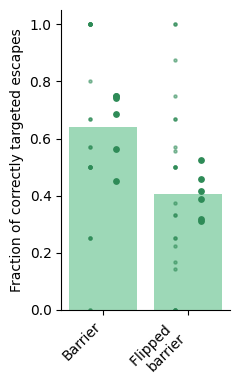

In [53]:
"""Plot the fraction of correct heading escapes in each condition"""

head_use = head
cond = ['Barrier','Flipped \nbarrier']
fig, axs = plt.subplots(1,1, figsize = (2.5,4))

fract_correct_esc = np.zeros((len(conditions),len(head_use['barrier_pre_flip'][:,1])))

non_zero_bar = np.sum(head_use['barrier_pre_flip'], axis = 1) > 0
fract_correct_esc[0,non_zero_bar] = head_use['barrier_pre_flip'][non_zero_bar,0]/np.sum(head_use['barrier_pre_flip'][non_zero_bar,:], axis = 1)

non_zero_flip = np.sum(head_use['barrier_post_flip'], axis = 1) > 0
fract_correct_esc[1,non_zero_flip] = head_use['barrier_post_flip'][non_zero_flip,2]/np.sum(head_use['barrier_post_flip'][non_zero_flip,:], axis = 1)

mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_fract = np.zeros((len(unique_mouse),np.shape(fract_correct_esc)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_fract[m_idx,:] = np.mean(fract_correct_esc[:,this_mouse], axis=1)

axs.bar(conditions,np.nanmean(fract_correct_esc, axis = 1),color = 'mediumseagreen',alpha = .5)
for i, c in enumerate(conditions):
    axs.scatter((np.ones(len(fract_correct_esc[i,:]))*i)-.15,fract_correct_esc[i,:],s = 5,c = 'seagreen', alpha = .5)
    axs.scatter((np.ones(len(mean_fract[:,i]))*i)+.15,mean_fract[:,i].T,s = 15,c = 'seagreen')

axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_ylim([0,1.05])
axs.set_ylabel('Fraction of correctly targeted escapes')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(save_path+'/'+str('Cosyne_fraction_correct_escapes.png'), dpi = 300)

# stats
good = np.hstack((fract_correct_esc[:,:7],fract_correct_esc[:,8:])) # remove stupid nan case
d1 = good[0,:]
d2 = good[1,:]
real_stat = np.abs(np.mean(d1)-np.mean(d2))
print('real stat: ' + str(real_stat))
d = np.hstack((d1,d2))
shuffled = np.zeros(1000)
for j in np.arange(1000):
    idx = np.random.uniform(low = 0,high = 1, size =len(d))
    d_sort = d[np.argsort(idx)]
    shuffled[j] = np.abs(np.mean(d_sort[:len(d1)]) - np.mean(d_sort[len(d1):]))
print(np.sum(shuffled > real_stat)/1000)